# 2D forced-dissipative turbulence


A simulation of forced-dissipative two-dimensional turbulence. We solve the
two-dimensional vorticity equation with stochastic excitation and dissipation in
the form of linear drag and hyperviscosity. As a demonstration, we compute how
each of the forcing and dissipation terms contribute to the energy budget.

In [1]:
using FourierFlows, Printf, Plots

using FourierFlows: parsevalsum
using Random: seed!
using FFTW: irfft

import GeophysicalFlows.TwoDNavierStokes
import GeophysicalFlows.TwoDNavierStokes: energy, enstrophy, dissipation, work, drag

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()    # Device (CPU/GPU)
nothing # hide

## Numerical, domain, and simulation parameters

First, we pick some numerical and physical parameters for our model.

In [3]:
 n, L  = 256, 2π             # grid resolution and domain length
 ν, nν = 2e-7, 2             # hyperviscosity coefficient and order
 μ, nμ = 1e-1, 0             # linear drag coefficient
dt, tf = 0.005, 0.2/μ        # timestep and final time
    nt = round(Int, tf/dt)   # total timesteps
    ns = 4                   # how many intermediate times we want to plot
nothing # hide

## Forcing

We force the vorticity equation with stochastic excitation that is delta-correlated
in time and while spatially homogeneously and isotropically correlated. The forcing
has a spectrum with power in a ring in wavenumber space of radious $k_f$ and
width $\delta k_f$, and it injects energy per unit area and per unit time equal
to $\varepsilon$.

In [4]:
forcing_wavenumber = 14.0    # the central forcing wavenumber for a spectrum that is a ring in wavenumber space
forcing_bandwidth  = 1.5     # the width of the forcing spectrum
ε = 0.001                    # energy input rate by the forcing

gr   = TwoDGrid(dev, n, L)
x, y = gr.x, gr.y

forcing_spectrum = @. exp(-(sqrt(gr.Krsq)-forcing_wavenumber)^2/(2*forcing_bandwidth^2))
forcing_spectrum[ gr.Krsq .< (2π/L*2)^2 ]  .= 0 # make sure that focing has no power for low wavenumbers
forcing_spectrum[ gr.Krsq .> (2π/L*20)^2 ] .= 0 # make sure that focing has no power for high wavenumbers
ε0 = parsevalsum(forcing_spectrum.*gr.invKrsq/2.0, gr)/(gr.Lx*gr.Ly)
forcing_spectrum .= ε/ε0 * forcing_spectrum # normalize forcing to inject energy ε

seed!(1234)
nothing # hide

Next we construct function `calcF!` that computes a forcing realization every timestep

In [5]:
function calcF!(Fh, sol, t, cl, v, p, g)
  ξ = ArrayType(dev)(exp.(2π*im*rand(eltype(gr), size(sol)))/sqrt(cl.dt))
  ξ[1, 1] = 0
  @. Fh = ξ*sqrt(forcing_spectrum)
  nothing
end
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments. The
`stepper` keyword defines the time-stepper to be used.

In [6]:
prob = TwoDNavierStokes.Problem(dev; nx=n, Lx=L, ν=ν, nν=nν, μ=μ, nμ=nμ, dt=dt, stepper="ETDRK4",
                                calcF=calcF!, stochastic=true)
nothing # hide

Define some shortcuts for convenience.

In [7]:
sol, cl, v, p, g = prob.sol, prob.clock, prob.vars, prob.params, prob.grid
nothing # hide

First let's see how a forcing realization looks like.

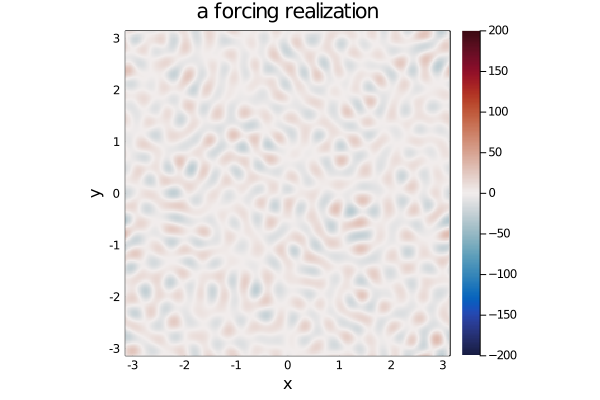

In [8]:
calcF!(v.Fh, sol, 0.0, cl, v, p, g)

heatmap(x, y, irfft(v.Fh, g.nx),
     aspectratio = 1,
               c = :balance,
            clim = (-200, 200),
           xlims = (-L/2, L/2),
           ylims = (-L/2, L/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "a forcing realization",
      framestyle = :box)

## Setting initial conditions

Our initial condition is simply fluid at rest.

In [9]:
TwoDNavierStokes.set_zeta!(prob, zeros(g.nx, g.ny))

## Diagnostics

Create Diagnostics; the diagnostics are aimed to probe the energy budget.

In [10]:
E = Diagnostic(energy,      prob, nsteps=nt) # energy
R = Diagnostic(drag,        prob, nsteps=nt) # dissipation by drag
D = Diagnostic(dissipation, prob, nsteps=nt) # dissipation by hyperviscosity
W = Diagnostic(work,        prob, nsteps=nt) # work input by forcing
diags = [E, D, W, R] # A list of Diagnostics types passed to "stepforward!" will  be updated every timestep.
nothing # hide

## Visualizing the simulation

We define a function that plots the vorticity field and the evolution of
the diagnostics: energy and all terms involved in the energy budget. Last
we confirm whether the energy budget is accurate, i.e., $\mathrm{d}E/\mathrm{d}t = W - R - D$.

In [11]:
function computetendencies_and_makeplot(prob, diags)
  TwoDNavierStokes.updatevars!(prob)
  E, D, W, R = diags

  clocktime = round(μ*cl.t, digits=2)

  i₀ = 1
  dEdt_numerical = (E[(i₀+1):E.i] - E[i₀:E.i-1])/cl.dt #numerical first-order approximation of energy tendency
  ii = (i₀):E.i-1
  ii2 = (i₀+1):E.i

  t = E.t[ii]
  dEdt_computed = W[ii2] - D[ii] - R[ii]        # Stratonovich interpretation

  residual = dEdt_computed - dEdt_numerical

  l = @layout grid(2, 2)

  p1 = heatmap(x, y, v.zeta,
            aspectratio = 1,
            legend = false,
                 c = :viridis,
              clim = (-25, 25),
             xlims = (-L/2, L/2),
             ylims = (-L/2, L/2),
            xticks = -3:3,
            yticks = -3:3,
            xlabel = "μt",
            ylabel = "y",
             title = "∇²ψ(x, y, t="*@sprintf("%.2f", cl.t)*")",
        framestyle = :box)

  p2 = plot(μ*t, [W[ii2] ε.+0*t -D[ii] -R[ii]],
             label = ["work, W" "ensemble mean work, <W>" "dissipation, D" "drag, D=-2μE"],
         linestyle = [:solid :dash :solid :solid],
         linewidth = 2,
             alpha = 0.8,
            xlabel = "μt",
            ylabel = "energy sources and sinks")

  p3 = plot(μ*t, [dEdt_computed[ii], dEdt_numerical],
             label = ["computed W-D" "numerical dE/dt"],
         linestyle = [:solid :dashdotdot],
         linewidth = 2,
             alpha = 0.8,
            xlabel = "μt",
            ylabel = "dE/dt")

  p4 = plot(μ*t, residual,
             label = "residual dE/dt = computed - numerical",
         linewidth = 2,
             alpha = 0.7,
            xlabel = "μt")

  p = plot(p1, p2, p3, p4, layout=l, size = (900, 800))
  return p
end
nothing # hide

## Time-stepping the `Problem` forward

Finally, we time-step the `Problem` forward in time.

In [12]:
startwalltime = time()
for i = 1:ns
  stepforward!(prob, diags, round(Int, nt/ns))
  TwoDNavierStokes.updatevars!(prob)
  cfl = cl.dt*maximum([maximum(v.u)/g.dx, maximum(v.v)/g.dy])

  log = @sprintf("step: %04d, t: %.1f, cfl: %.3f, walltime: %.2f min", cl.step, cl.t,
        cfl, (time()-startwalltime)/60)

  println(log)
end

step: 0100, t: 0.5, cfl: 0.016, walltime: 0.04 min
step: 0200, t: 1.0, cfl: 0.023, walltime: 0.06 min
step: 0300, t: 1.5, cfl: 0.029, walltime: 0.08 min
step: 0400, t: 2.0, cfl: 0.029, walltime: 0.10 min


## Plot
And now let's see what we got. We plot the output.

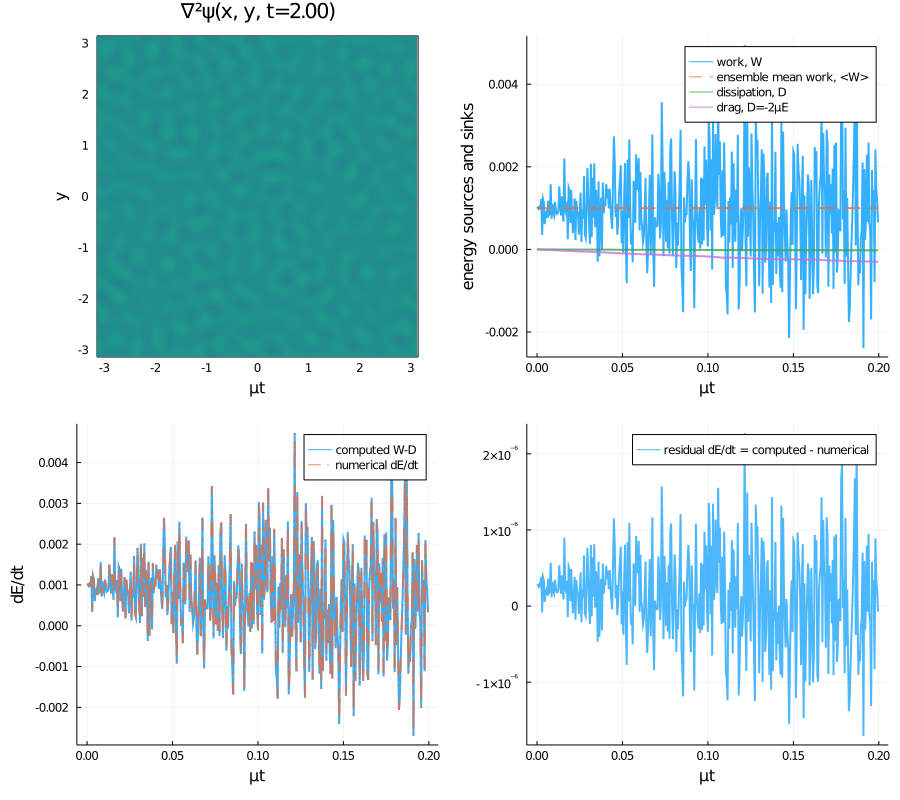

In [13]:
p = computetendencies_and_makeplot(prob, diags)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*